"""
Linear Discriminant Analysis
is generally used in supervised learning algorithms as a classifier to separate
the input data into two or more classes. It is also a dimensionality reduction
technique.
"""

In [ ]:
import numpy as np
from sklearn.datasets import load_iris

# ────────────────────────────────────────────────
#  Load Iris dataset
# ────────────────────────────────────────────────
iris = load_iris()
X = iris.data          # shape (150, 4)
y = iris.target        # 0,1,2
class_names = iris.target_names  # ['setosa', 'versicolor', 'virginica']

n_samples, n_features = X.shape
n_classes = len(np.unique(y))

print(f"Dataset: {n_samples} samples, {n_features} features, {n_classes} classes\n")

# ────────────────────────────────────────────────
# 1. Compute overall mean μ
# ────────────────────────────────────────────────
mu = np.mean(X, axis=0)
print("Overall mean μ:")
print(np.round(mu, 4), "\n")

# ────────────────────────────────────────────────
# 2. Class means & counts
# ────────────────────────────────────────────────
means = np.zeros((n_classes, n_features))
counts = np.zeros(n_classes)

for c in range(n_classes):
    mask = (y == c)
    counts[c] = np.sum(mask)
    means[c] = np.mean(X[mask], axis=0)
    print(f"Class {c} ({class_names[c]:12})  n = {int(counts[c]):3d}   mean = {np.round(means[c], 4)}")

# ────────────────────────────────────────────────
# 3. Between-class scatter SB
# ────────────────────────────────────────────────
SB = np.zeros((n_features, n_features))
for c in range(n_classes):
    diff = (means[c] - mu).reshape(-1, 1)
    SB += counts[c] * (diff @ diff.T)

print("\nBetween-class scatter SB:")
print(np.round(SB, 4))

# ────────────────────────────────────────────────
# 4. Within-class scatter SW
# ────────────────────────────────────────────────
SW = np.zeros((n_features, n_features))
for c in range(n_classes):
    mask = (y == c)
    diff = X[mask] - means[c]
    SW += diff.T @ diff

print("\nWithin-class scatter SW:")
print(np.round(SW, 4))

# ────────────────────────────────────────────────
# 5. Compute M = SW⁻¹ SB
# ────────────────────────────────────────────────
SW_inv = np.linalg.inv(SW)          # SW should be invertible for Iris
M = SW_inv @ SB

print("\nM = SW⁻¹ SB:")
print(np.round(M, 4))

# ────────────────────────────────────────────────
# 6. Very simple power iteration to find dominant eigenvector
# ────────────────────────────────────────────────
def simple_power_iteration(A, max_iter=100, tol=1e-9):
    n = A.shape[0]
    v = np.random.rand(n)
    v /= np.linalg.norm(v) + 1e-12
    
    for it in range(max_iter):
        v_new = A @ v
        eigenvalue = v @ v_new           # Rayleigh quotient
        v_new /= np.linalg.norm(v_new) + 1e-12
        
        if np.abs(np.dot(v, v_new) - 1.0) < tol:
            break
        v = v_new
    
    return eigenvalue, v, it + 1


# Find first (largest) eigenpair
lam1, v1, iter1 = simple_power_iteration(M)
v1 = v1 / np.linalg.norm(v1)          # ensure unit length

print(f"\n→ Largest eigenvalue ≈ {lam1:.6f}  (found in {iter1} iterations)")
print("Eigenvector 1:", np.round(v1, 6))

# Deflate matrix to find second direction
M_deflated = M - lam1 * np.outer(v1, v1)

lam2, v2, iter2 = simple_power_iteration(M_deflated)
v2 = v2 / np.linalg.norm(v2)

print(f"→ Second eigenvalue ≈ {lam2:.6f}  (found in {iter2} iterations)")
print("Eigenvector 2:", np.round(v2, 6))

# ────────────────────────────────────────────────
# 7. Projection matrix W (first two eigenvectors as columns)
# ────────────────────────────────────────────────
W = np.column_stack((v1, v2))

# Project all data to 2D
X_lda = X @ W

# ────────────────────────────────────────────────
# 8. Show some results
# ────────────────────────────────────────────────
print("\nFirst 6 projected points (should be mostly setosa):")
print(np.round(X_lda[:6], 4))

print("\nClass centers in the 2D LDA space:")
for c in range(n_classes):
    center = np.mean(X_lda[y == c], axis=0)
    print(f"{class_names[c]:12} : {np.round(center, 4)}")

## Step - 0 Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np

## Step - 1 Load the dataset

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data'

data = pd.read_csv(url,header=None)# read url(The URL must be a string with full slashes)
# url = " httpsarchive.ics.uci.edumlmachine-learning-databasesbalance-scalebalance-scale.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data"

# Declare the column names(This dataset does not have a header row, so we define column names manually)
col_names = ['Class Name', 'Left-Weight', 'Left-Distance', 'Right-Weight', 'Right-Distance']

#Read the data in the url using read_csv 
data = pd.read_csv(url,header=None,names=col_names)

data = pd.DataFrame(data)
print(data.head())


  Class Name  Left-Weight  Left-Distance  Right-Weight  Right-Distance
0          B            1              1             1               1
1          R            1              1             1               2
2          R            1              1             1               3
3          R            1              1             1               4
4          R            1              1             1               5


## Step 3 - Preprocess the Dataset

In [ ]:
#Class name is categorical so we keep it aside 
x = data.drop('Class Name', axis = 1)

#then we store it seperately as Y
Y = data['Class Name']

print(x.head())


   Left-Weight  Left-Distance  Right-Weight  Right-Distance
0            1              1             1               1
1            1              1             1               2
2            1              1             1               3
3            1              1             1               4
4            1              1             1               5


In [21]:
#Make sure you convert the integer values of X in to decimal values
X = x.to_numpy().astype(float)

# Map class labels to integers 0,1,2,... (L = left, B = balance, R = right)
class_map = {name: i for i, name in enumerate(sorted(Y.unique()))}
y = Y.map(class_map).to_numpy()

print(X)
print("Mapping of class labels are :",class_map)


[[1. 1. 1. 1.]
 [1. 1. 1. 2.]
 [1. 1. 1. 3.]
 ...
 [5. 5. 5. 3.]
 [5. 5. 5. 4.]
 [5. 5. 5. 5.]]
Mapping of class labels are : {'B': 0, 'L': 1, 'R': 2}


In [22]:
class_names = sorted(class_map.keys())         # e.g. ['B', 'L', 'R']
n_samples, n_features = X.shape
n_classes = len(class_names)
print(f"Dataset: {n_samples} samples, {n_features} features, {n_classes} classes")
print(f"Classes : {class_names}\n")

Dataset: 625 samples, 4 features, 3 classes
Classes : ['B', 'L', 'R']



# Procedure



## ────────────────────────────────────────────────
## 1. Overall mean μ
## ────────────────────────────────────────────────

In [23]:
mu = np.mean(X,axis=0)
print("Overall mean μ:")
print(np.round(mu,4),"\n")

Overall mean μ:
[3. 3. 3. 3.] 



## ────────────────────────────────────────────────
## 2. Class means & counts
## ────────────────────────────────────────────────

In [32]:
means = np.zeros((n_classes, n_features))
counts = np.zeros(n_classes)

for i, name in enumerate((n_classes, n_features)) :
    mask = (y==i)
    counts[i] = np.sum(mask)
    means[i] = np.mean(X[mask], axis=0) if counts[i] > 0 else np.zeros(n_features)
    print(f"Class {i} ({name:2})   n = {int(counts[i]):4d}   mean = {np.round(means[i], 4)}")
    

Class 0 ( 3)   n =   49   mean = [2.9388 2.9388 2.9388 2.9388]
Class 1 ( 4)   n =  288   mean = [3.6111 3.6111 2.3993 2.3993]


## ────────────────────────────────────────────────
## 3. Between-class scatter SB
## ────────────────────────────────────────────────

In [ ]:
SB = np.zeros((n_features, n_features))
for i in range(n_classes) :
    diff  = (means[i] - mu).reshape(-1,1) # Calculates the difference between the 
                                          # class mean (mi) and the global 
                                          # mean (mu). It then reshapes this 
                                          # into a column vector (d * 1) 
                                          # to prepare for matrix multiplication.
    SB += counts[i] * (diff @ diff.T)     # diff @ diff.T - (Xi - mu)*(Xi - mu)T performs an outer product, resulting in a d*d matrix.
                                          # counts[i] - Ni
print("\nBetween-class scatter SB:")
print(np.round(SB, 4))



Between-class scatter SB:
[[ 107.7392  107.7392 -105.5385 -105.5385]
 [ 107.7392  107.7392 -105.5385 -105.5385]
 [-105.5385 -105.5385  104.1038  104.1038]
 [-105.5385 -105.5385  104.1038  104.1038]]


## ────────────────────────────────────────────────
## 4. Within-class scatter SB
## ────────────────────────────────────────────────

In [ ]:
SW = np.zeros((n_features, n_features))

for i in range(n_classes) :
    mask = (y==i)                    # Creates a boolean filter to select only the 
                                     # rows in X belonging to the current class \(i\).
    if np.sum(mask) > 1 :         
        diff = X[mask] - means[i]    # Centers the data for class \(i\) by subtracting 
                                     # the class mean from every sample in that class.
        SW += diff.T @ diff        
print("\nWithin-class scatter SW:")
print(np.round(SW, 4))


Within-class scatter SW:
[[2696.2608 1446.2608 2706.5385 2706.5385]
 [1446.2608 2696.2608 2706.5385 2706.5385]
 [2706.5385 2706.5385 4793.8962 3543.8962]
 [2706.5385 2706.5385 3543.8962 4793.8962]]


## ────────────────────────────────────────────────
## 5. Compute M = SW⁻¹ SB
## ────────────────────────────────────────────────
### Important: for the balance-scale dataset SW is often singular → use pseudo-inverse

In [36]:
try : 
    SW_inv = np.linalg.inv(SW)
    print(" -> SW is invertible")
except np.linalg.LinAlgError :
    print("-> SW is singular -> using pseudo-inverse")
    SW_inv = np.linalg.pinv(SW)

M = SW_inv @ SB
print("\nM = SW⁻¹ SB (or pseudo-inverse):")
print(np.round(M, 4))

 -> SW is invertible

M = SW⁻¹ SB (or pseudo-inverse):
[[ 0.2806  0.2806 -0.2756 -0.2756]
 [ 0.2806  0.2806 -0.2756 -0.2756]
 [-0.1948 -0.1948  0.1914  0.1914]
 [-0.1948 -0.1948  0.1914  0.1914]]


## ────────────────────────────────────────────────
## 6. Simple power iteration – find dominant eigenvectors
## ────────────────────────────────────────────────

In [37]:
def simple_power_iteration(A,max_iter=200, tol =1e-10) :
    n = A.shape[0]
    v = np.random.rand(n)
    v /= np.linalg.norm(v) + 1e-12

    for it in range(max_iter):
        v_new = A @ v
        eigenvalue = v @ v_new
        v_new /= np.linalg.norm(v_new) + 1e-12

        if np.abs(np.dot(v, v_new) - 1.0) < tol:
            break
        v = v_new

    return eigenvalue, v, it + 1



In [38]:
# First direction (largest eigenvalue)
lam1, v1, iter1 = simple_power_iteration(M)
v1 = v1 / np.linalg.norm(v1)
print(f"\n→ Largest eigenvalue ≈ {lam1:.6f} (found in {iter1} iterations)")
print("Direction 1:", np.round(v1, 6))

# Deflate and find second direction
M_deflated = M - lam1 * np.outer(v1, v1)
lam2, v2, iter2 = simple_power_iteration(M_deflated)
v2 = v2 / np.linalg.norm(v2)
print(f"→ Second eigenvalue ≈ {lam2:.6f} (found in {iter2} iterations)")
print("Direction 2:", np.round(v2, 6))

# ────────────────────────────────────────────────
# 7. Projection matrix W (top-2 directions)
# ────────────────────────────────────────────────
W = np.column_stack((v1, v2))

# Project data to 2D LDA space
X_lda = X @ W

# ────────────────────────────────────────────────
# 8. Results summary
# ────────────────────────────────────────────────
print("\nClass centers in the 2D LDA space:")
for i, name in enumerate(class_names):
    center = np.mean(X_lda[y == i], axis=0)
    print(f"{name:6} : {np.round(center, 4)}")

# Optional: show a few projected points
print("\nFirst 8 projected points:")
print(np.round(X_lda[:8], 4))


→ Largest eigenvalue ≈ 0.943846 (found in 3 iterations)
Direction 1: [-0.580804 -0.580804  0.40332   0.40332 ]
→ Second eigenvalue ≈ 0.000205 (found in 200 iterations)
Direction 2: [-0.58069  -0.58069   0.403484  0.403484]

Class centers in the 2D LDA space:
B      : [-1.0432 -1.0415]
L      : [-2.2593 -2.2577]
R      : [0.1258 0.1275]

First 8 projected points:
[[-0.355  -0.3544]
 [ 0.0484  0.0491]
 [ 0.4517  0.4526]
 [ 0.855   0.856 ]
 [ 1.2583  1.2595]
 [ 0.0484  0.0491]
 [ 0.4517  0.4526]
 [ 0.855   0.856 ]]


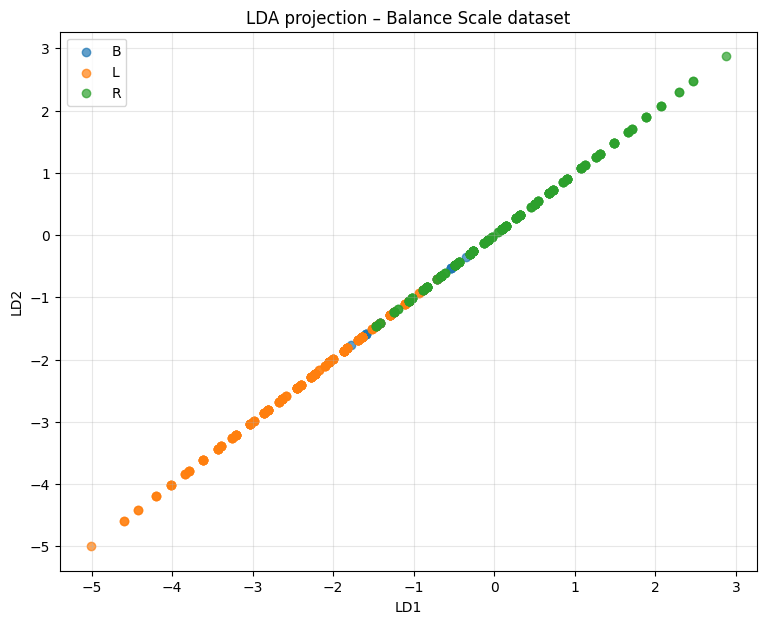

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
for i, name in enumerate(class_names):
    mask = (y == i)
    plt.scatter(X_lda[mask,0], X_lda[mask,1], label=name, alpha=0.7)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA projection – Balance Scale dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()